# Análisis Exploratorio de las imágenes

### Importación de librerías

In [29]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('grayscale')

ruta_datos = Path("../../data/PPMI")

#### Extracción de un sujeto

In [ ]:
def cargar_volumen_dicom(ruta_carpeta_serie):
    archivos = list(Path(ruta_carpeta_serie).glob("*.dcm"))
    if not archivos:
        return None, None
        
    cortes = []
    for archivo in archivos:
        try:
            corte = pydicom.dcmread(archivo)
            # Filtramos: solo guardamos el DICOM si realmente contiene una imagen
            if hasattr(corte, 'PixelData'):
                cortes.append(corte)
        except:
            pass
            
    if not cortes:
        return None, None

    # Funcion segura para extraer la posicion Z (orden de los cortes)
    def obtener_posicion_z(corte):
        if hasattr(corte, 'ImagePositionPatient'):
            return float(corte.ImagePositionPatient[2])
        elif hasattr(corte, 'SliceLocation'):
            return float(corte.SliceLocation)
        elif hasattr(corte, 'InstanceNumber'):
            return float(corte.InstanceNumber)
        return 0.0

    cortes.sort(key=obtener_posicion_z)
    
    espaciado_pixel = cortes[0].PixelSpacing if hasattr(cortes[0], 'PixelSpacing') else [1.0, 1.0]
    grosor_corte = cortes[0].SliceThickness if hasattr(cortes[0], 'SliceThickness') else 1.0
    
    espaciado_3d = (float(grosor_corte), float(espaciado_pixel[0]), float(espaciado_pixel[1]))
    
    try:
        volumen = np.stack([corte.pixel_array for corte in cortes])
    except ValueError:
        return None, None
        
    return volumen, espaciado_3d

carpetas_sujetos = [d for d in ruta_datos.iterdir() if d.is_dir()]
sujeto_prueba = carpetas_sujetos[0]

carpetas_internas = [x[0] for x in os.walk(sujeto_prueba) if any(f.endswith('.dcm') for f in x[2])]
ruta_serie_prueba = carpetas_internas[0]

volumen_3d, espaciado = cargar_volumen_dicom(ruta_serie_prueba)

if volumen_3d is not None:
    print(f"Sujeto cargado: {sujeto_prueba.name}")
    print(f"Dimensiones de la matriz 3D: {volumen_3d.shape}")
    print(f"Resolucion fisica (Z, X, Y) en mm: {espaciado}")
else:
    print(f"No se pudo cargar un volumen valido para el sujeto {sujeto_prueba.name}")

Sujeto cargado: 100001
Dimensiones de la matriz 3D: (192, 256, 256)
Resolucion fisica (Z, X, Y) en mm: (1.0, 1.0, 1.0)


### Imágenes centrales del sujeto

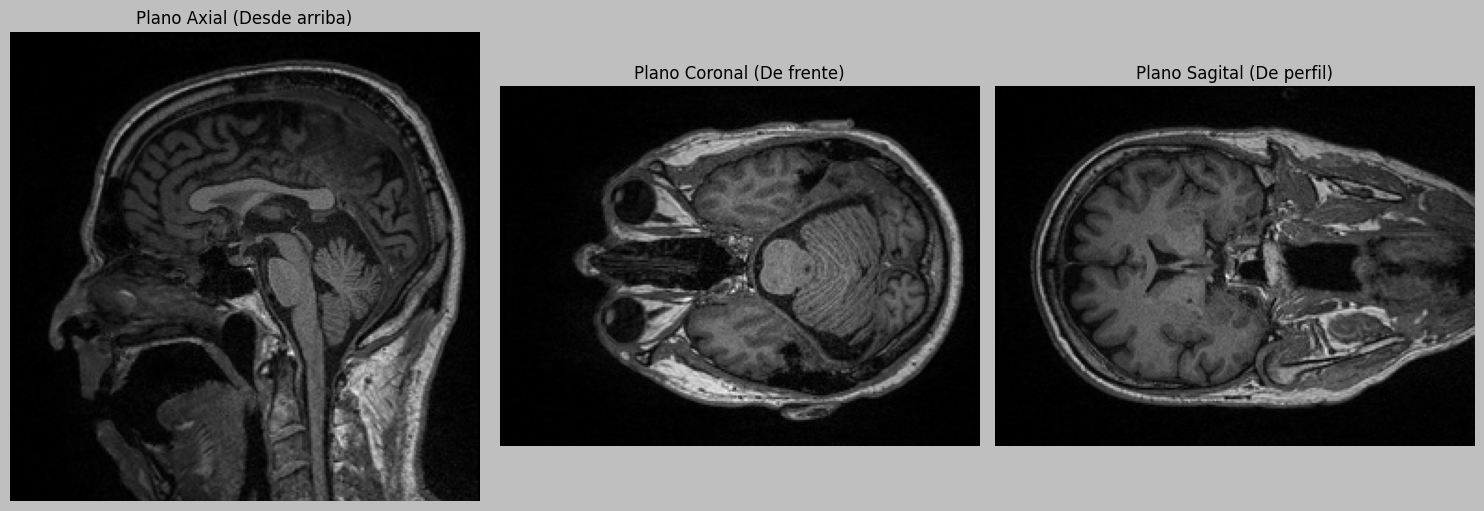

In [31]:
centro_z = volumen_3d.shape[0] // 2
centro_y = volumen_3d.shape[1] // 2
centro_x = volumen_3d.shape[2] // 2

corte_axial = volumen_3d[centro_z, :, :]
corte_coronal = volumen_3d[:, centro_y, :]
corte_sagital = volumen_3d[:, :, centro_x]

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

ejes[0].imshow(corte_axial)
ejes[0].set_title("Plano Axial (Desde arriba)")
ejes[0].axis('off')

ejes[1].imshow(corte_coronal)
ejes[1].set_title("Plano Coronal (De frente)")
ejes[1].axis('off')

ejes[2].imshow(corte_sagital)
ejes[2].set_title("Plano Sagital (De perfil)")
ejes[2].axis('off')

plt.tight_layout()
plt.show()

#### Intensidad de los pixeles

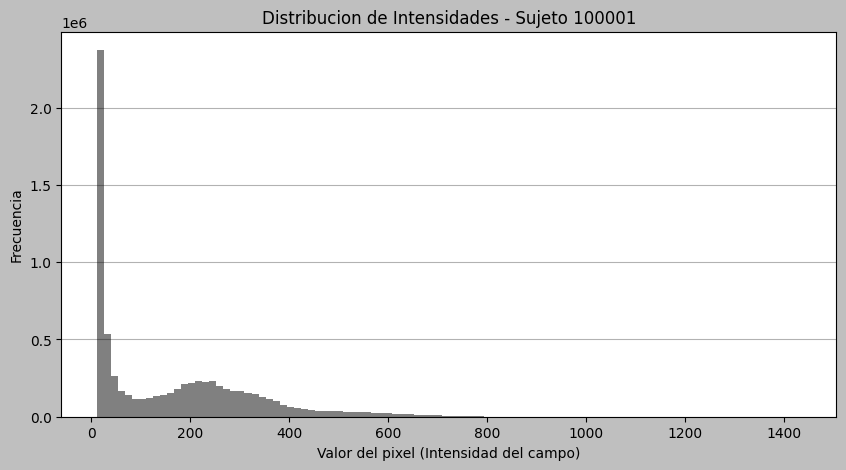

Intensidad minima: 11
Intensidad maxima: 1435
Intensidad media: 165.11


In [32]:
pixeles_cerebro = volumen_3d[volumen_3d > 10]

plt.figure(figsize=(10, 5))
plt.hist(pixeles_cerebro.flatten(), bins=100, color='gray')
plt.title(f"Distribucion de Intensidades - Sujeto {sujeto_prueba.name}")
plt.xlabel("Valor del pixel (Intensidad del campo)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Intensidad minima: {np.min(pixeles_cerebro)}")
print(f"Intensidad maxima: {np.max(pixeles_cerebro)}")
print(f"Intensidad media: {np.mean(pixeles_cerebro):.2f}")

#### Dimensiones y resoluciones de las imagenes

In [33]:
dimensiones_encontradas = []
espaciados_encontrados = []

print(f"Iniciando auditoria de {len(carpetas_sujetos)} pacientes. Esto puede tardar varios minutos...")

for indice, paciente in enumerate(carpetas_sujetos):
    carpetas_dicom = [x[0] for x in os.walk(paciente) if any(f.endswith('.dcm') for f in x[2])]
    if carpetas_dicom:
        volumen, espaciado = cargar_volumen_dicom(carpetas_dicom[0])
        if volumen is not None:
            dimensiones_encontradas.append(str(volumen.shape))
            espacios_formateados = f"({espaciado[0]:.2f}, {espaciado[1]:.2f}, {espaciado[2]:.2f})"
            espaciados_encontrados.append(espacios_formateados)
            
    if (indice + 1) % 50 == 0:
        print(f"Procesados {indice + 1} pacientes...")

print("Auditoria general completada.\n")

print("Variedad de dimensiones de matriz detectadas:")
for dimension in set(dimensiones_encontradas):
    conteo = dimensiones_encontradas.count(dimension)
    print(f"- {dimension} : {conteo} pacientes")

print("\nVariedad de resoluciones fisicas (espaciado voxel) detectadas:")
for espaciado in set(espaciados_encontrados):
    conteo = espaciados_encontrados.count(espaciado)
    print(f"- {espaciado} : {conteo} pacientes")

Iniciando auditoria de 954 pacientes. Esto puede tardar varios minutos...
Procesados 50 pacientes...
Procesados 100 pacientes...
Procesados 150 pacientes...
Procesados 200 pacientes...
Procesados 250 pacientes...
Procesados 300 pacientes...
Procesados 350 pacientes...
Procesados 400 pacientes...
Procesados 450 pacientes...
Procesados 500 pacientes...
Procesados 550 pacientes...
Procesados 600 pacientes...
Procesados 650 pacientes...
Procesados 700 pacientes...
Procesados 750 pacientes...
Procesados 800 pacientes...
Procesados 850 pacientes...
Procesados 900 pacientes...
Procesados 950 pacientes...
Auditoria general completada.

Variedad de dimensiones de matriz detectadas:
- (136, 256, 256) : 1 pacientes
- (84, 512, 512) : 6 pacientes
- (384, 512, 512) : 14 pacientes
- (102, 256, 256) : 3 pacientes
- (96, 512, 512) : 2 pacientes
- (211, 256, 256) : 11 pacientes
- (78, 512, 512) : 2 pacientes
- (208, 256, 216) : 1 pacientes
- (156, 512, 512) : 1 pacientes
- (188, 256, 256) : 42 paciente